# 06. Train ESM-2 (Protein Language Model) + GRU Baseline

Pretrained Protein Language Model baseline for PTM site prediction:
- **Representation**: Pretrained Evolutionary Scale Modeling (ESM-2 `esm2_t12_35M_UR50D`), 31 positions × 480 embedding dimensions.
- **Architecture**: Frozen ESM-2 sequence embeddings fed into Bidirectional GRU layers + Multi-label classification heads.
- **Post-Processing**: Threshold optimization sweeping [0.05, 0.95] to address severe class imbalance.

In [ ]:
#!conda install numpy pandas scipy scikit-learn matplotlib seaborn
#!pip install tensorflow fair-esm
#!pip install torch --index-url https://download.pytorch.org/whl/cu121

## 1. Configuration

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, confusion_matrix
)
import pickle
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Deep learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    Bidirectional, GRU
)

# ESM-2 imports
try:
    import torch
    import esm
    ESM_AVAILABLE = True
    print("ESM-2 library imported successfully")
    print(f"PyTorch version: {torch.__version__}")
    print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
except ImportError:
    ESM_AVAILABLE = False
    print("ERROR: ESM-2 library not found. Please install: pip install fair-esm torch")

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

ESM-2 library imported successfully
PyTorch version: 2.4.1+cu121
Device: cpu
TensorFlow version: 2.20.0
Keras version: 3.12.0
NumPy version: 2.2.6
Pandas version: 2.3.3


In [ ]:
# =====================================================================
# CONFIGURATION
# =====================================================================

# Training Strategy
USE_FINETUNING = False  # Set to True to enable Phase 2 fine-tuning (GPU recommended)

# Experiment name
EXPERIMENT_NAME = "run01_frozen_esm2"  # Options: "run01_frozen_esm2", "run02_frozen_esm2_augmented_v2"

# ESM-2 Model Selection
ESM_MODEL_NAME = "esm2_t12_35M_UR50D"

# Data file paths
if "augmented" in EXPERIMENT_NAME and os.path.exists("../data_engineered/train_augmented_v2_with_features_default_split.csv"):
    TRAIN_FILE = "../data_engineered/train_augmented_v2_with_features_default_split.csv"
    VAL_FILE = "../data_engineered/val_augmented_v2_with_features_default_split.csv"
else:
    TRAIN_FILE = "../data_engineered/train_with_features_split.csv"
    VAL_FILE = "../data_engineered/val_with_features_split.csv"

OUTPUT_DIR = f"../output/transformer_gru/{EXPERIMENT_NAME}"
CACHE_DIR = f"../output/transformer_gru/{EXPERIMENT_NAME}/transformer_cache"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# Training Hyperparameters
BATCH_SIZE = 64
EPOCHS_FROZEN = 30
LEARNING_RATE_FROZEN = 1e-3
EARLY_STOPPING_PATIENCE = 7

# Model Architecture
GRU_UNITS = 128
DENSE_UNITS = 64
DROPOUT_RATE = 0.3

# Class labels
LABEL_COLS = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']
NUM_CLASSES = len(LABEL_COLS)

print(f"ESM-2 + GRU Configuration:")
print(f"  Experiment:       {EXPERIMENT_NAME}")
print(f"  ESM Model:        {ESM_MODEL_NAME}")
print(f"  Train File:       {TRAIN_FILE}")
print(f"  Val File:         {VAL_FILE}")
print(f"  Output Directory: {OUTPUT_DIR}")
print(f"  Cache Directory:  {CACHE_DIR}")

## 2. Load Data

In [52]:
# Load train and validation splits
train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")

# Label columns
label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']

# Extract sequences and labels
train_sequences = train_df['Sequence'].values
val_sequences = val_df['Sequence'].values

y_train = train_df[label_cols].values.astype(np.float32)
y_val = val_df[label_cols].values.astype(np.float32)

print(f"\nSequence length: {len(train_sequences[0])}")
print(f"Example sequence: {train_sequences[0]}")

# Check class distribution
print("\nClass Distribution:")
for i, label in enumerate(label_cols):
    pos_train = y_train[:, i].sum()
    pos_val = y_val[:, i].sum()
    print(f"{label}:")
    print(f"  Train: {pos_train:,} positive ({pos_train/len(y_train)*100:.2f}%)")
    print(f"  Val:   {pos_val:,} positive ({pos_val/len(y_val)*100:.2f}%)")

Training samples: 76,341
Validation samples: 19,086

Sequence length: 31
Example sequence: AAAAAAEDSFGSSHDCSSGTYFPEQSDLEPP

Class Distribution:
S-glutathionylation:
  Train: 4,622.0 positive (6.05%)
  Val:   1,155.0 positive (6.05%)
S-nitrosylation:
  Train: 12,894.0 positive (16.89%)
  Val:   3,224.0 positive (16.89%)
S-palmitoylation:
  Train: 3,798.0 positive (4.98%)
  Val:   950.0 positive (4.98%)


## 3. Load ESM-2 Model and Extract Embeddings

In [53]:
def extract_esm2_embeddings(sequences, model, alphabet, batch_size=32, device='cpu'):
    """
    Extract per-residue embeddings from ESM-2 model.
    
    Parameters:
    -----------
    sequences : array-like
        List of protein sequences (strings)
    model : ESM model
        Pre-trained ESM-2 model
    alphabet : ESM alphabet
        Tokenizer for converting sequences to token IDs
    batch_size : int
        Batch size for extraction
    device : str
        'cpu' or 'cuda'
    
    Returns:
    --------
    embeddings : np.ndarray
        Shape (n_samples, seq_len, embedding_dim)
    """
    model = model.to(device)
    model.eval()
    
    batch_converter = alphabet.get_batch_converter()
    all_embeddings = []
    
    print(f"Extracting embeddings for {len(sequences):,} sequences...")
    
    for i in range(0, len(sequences), batch_size):
        batch_sequences = sequences[i:i+batch_size]
        
        # Prepare batch: format as [(label, sequence), ...]
        batch_labels = [(f"seq_{j}", seq) for j, seq in enumerate(batch_sequences)]
        _, _, batch_tokens = batch_converter(batch_labels)
        batch_tokens = batch_tokens.to(device)
        
        # Extract embeddings
        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[model.num_layers])
            # Get embeddings from last layer
            embeddings = results["representations"][model.num_layers]
            
            # Remove special tokens (BOS and EOS)
            # ESM adds <cls> token at start and <eos> token at end
            embeddings = embeddings[:, 1:-1, :]  # (batch, seq_len, embed_dim)
            
            all_embeddings.append(embeddings.cpu().numpy())
        
        if (i + batch_size) % 1000 == 0 or (i + batch_size) >= len(sequences):
            print(f"  Processed {min(i+batch_size, len(sequences)):,}/{len(sequences):,} sequences")
    
    # Concatenate all batches
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    print(f"Embedding shape: {all_embeddings.shape}")
    
    return all_embeddings

In [54]:
# Load ESM-2 model
if not ESM_AVAILABLE:
    raise ImportError("ESM-2 library not available. Please install: pip install fair-esm torch")

print(f"Loading ESM-2 model: {ESM_MODEL_NAME}...")
esm_model, alphabet = esm.pretrained.load_model_and_alphabet(ESM_MODEL_NAME)
esm_model.eval()

# Determine device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Get embedding dimension from model
EMBEDDING_DIM = esm_model.embed_dim
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"Model layers: {esm_model.num_layers}")

Loading ESM-2 model: esm2_t12_35M_UR50D...
Using device: cpu
Embedding dimension: 480
Model layers: 12


In [55]:
# Extract or load cached embeddings
train_cache_path = os.path.join(CACHE_DIR, f"train_embeddings_{ESM_MODEL_NAME}.npy")
val_cache_path = os.path.join(CACHE_DIR, f"val_embeddings_{ESM_MODEL_NAME}.npy")

# Training embeddings
if os.path.exists(train_cache_path):
    print(f"Loading cached training embeddings from {train_cache_path}")
    X_train_embed = np.load(train_cache_path)
    print(f"Loaded training embeddings: {X_train_embed.shape}")
else:
    print("Extracting training embeddings (this may take 1-2 hours)...")
    X_train_embed = extract_esm2_embeddings(
        train_sequences,
        esm_model,
        alphabet,
        batch_size=BATCH_SIZE,
        device=device
    )
    print(f"Saving training embeddings to {train_cache_path}")
    np.save(train_cache_path, X_train_embed)
    print(f"Training embeddings saved: {X_train_embed.shape}")

# Validation embeddings
if os.path.exists(val_cache_path):
    print(f"\nLoading cached validation embeddings from {val_cache_path}")
    X_val_embed = np.load(val_cache_path)
    print(f"Loaded validation embeddings: {X_val_embed.shape}")
else:
    print("\nExtracting validation embeddings (this may take 20-30 minutes)...")
    X_val_embed = extract_esm2_embeddings(
        val_sequences,
        esm_model,
        alphabet,
        batch_size=BATCH_SIZE,
        device=device
    )
    print(f"Saving validation embeddings to {val_cache_path}")
    np.save(val_cache_path, X_val_embed)
    print(f"Validation embeddings saved: {X_val_embed.shape}")

print("\n" + "="*70)
print("EMBEDDINGS READY")
print("="*70)
print(f"Training: {X_train_embed.shape}")
print(f"Validation: {X_val_embed.shape}")
print("="*70)

Extracting training embeddings (this may take 1-2 hours)...
Extracting embeddings for 76,341 sequences...
  Processed 4,000/76,341 sequences
  Processed 8,000/76,341 sequences
  Processed 12,000/76,341 sequences
  Processed 16,000/76,341 sequences
  Processed 20,000/76,341 sequences
  Processed 24,000/76,341 sequences
  Processed 28,000/76,341 sequences
  Processed 32,000/76,341 sequences
  Processed 36,000/76,341 sequences
  Processed 40,000/76,341 sequences
  Processed 44,000/76,341 sequences
  Processed 48,000/76,341 sequences
  Processed 52,000/76,341 sequences
  Processed 56,000/76,341 sequences
  Processed 60,000/76,341 sequences
  Processed 64,000/76,341 sequences
  Processed 68,000/76,341 sequences
  Processed 72,000/76,341 sequences
  Processed 76,000/76,341 sequences
  Processed 76,341/76,341 sequences
Embedding shape: (76341, 31, 480)
Saving training embeddings to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_cache/train_embeddings_esm2_t12_35M_UR50D.n

## 4. Calculate Class Weights

In [56]:
def calculate_class_weights(y_train, dampen_factor=0.5):
    """
    Calculate dampened class weights for multi-label classification.
    
    For severe imbalance, full inverse ratio can cause instability.
    We dampen the weights: weight = (neg/pos) ** dampen_factor
    
    Parameters:
    -----------
    y_train : np.ndarray
        Training labels, shape (n_samples, n_labels)
    dampen_factor : float
        Exponent for dampening (0.5 = square root dampening)
    
    Returns:
    --------
    class_weights : np.ndarray
        Weights for each label, shape (n_labels,)
    """
    class_weights = []
    
    print("\nClass Weights Calculation:")
    print("-" * 70)
    
    for i in range(y_train.shape[1]):
        pos = y_train[:, i].sum()
        neg = len(y_train) - pos
        
        # Calculate dampened weight
        ratio = neg / pos
        weight = ratio ** dampen_factor
        
        class_weights.append(weight)
        
        print(f"{label_cols[i]}:")
        print(f"  Positive: {pos:,} ({pos/len(y_train)*100:.2f}%)")
        print(f"  Negative: {neg:,} ({neg/len(y_train)*100:.2f}%)")
        print(f"  Ratio (neg/pos): {ratio:.2f}")
        print(f"  Dampened weight: {weight:.2f}")
        print()
    
    class_weights = np.array(class_weights, dtype=np.float32)
    print("-" * 70)
    
    return class_weights

class_weights = calculate_class_weights(y_train, dampen_factor=DAMPEN_FACTOR)


Class Weights Calculation:
----------------------------------------------------------------------
S-glutathionylation:
  Positive: 4,622.0 (6.05%)
  Negative: 71,719.0 (93.95%)
  Ratio (neg/pos): 15.52
  Dampened weight: 3.94

S-nitrosylation:
  Positive: 12,894.0 (16.89%)
  Negative: 63,447.0 (83.11%)
  Ratio (neg/pos): 4.92
  Dampened weight: 2.22

S-palmitoylation:
  Positive: 3,798.0 (4.98%)
  Negative: 72,543.0 (95.02%)
  Ratio (neg/pos): 19.10
  Dampened weight: 4.37

----------------------------------------------------------------------


## 5. Build Transformer+GRU Model

In [57]:
def build_transformer_gru_model(
    seq_length,
    embedding_dim,
    gru_units=[128, 64],
    dense_units=[128, 64],
    dropout_recurrent=0.2,
    dropout_dense=0.3,
    n_outputs=3
):
    """
    Build Transformer+GRU model for multi-label classification.
    
    Architecture:
    - Input: Pre-extracted transformer embeddings (seq_length, embedding_dim)
    - Bidirectional GRU layers for sequential pattern learning
    - Dense layers for final classification
    
    Parameters:
    -----------
    seq_length : int
        Sequence length (31 for our data)
    embedding_dim : int
        Embedding dimension from transformer (480 for esm2_t12)
    gru_units : list
        Number of units in each GRU layer
    dense_units : list
        Number of units in each dense layer
    dropout_recurrent : float
        Dropout rate for GRU layers
    dropout_dense : float
        Dropout rate for dense layers
    n_outputs : int
        Number of output labels (3 for our task)
    
    Returns:
    --------
    model : keras.Model
        Compiled model
    """
    inputs = Input(shape=(seq_length, embedding_dim), name='embedding_input')
    
    # Bidirectional GRU layers
    x = inputs
    for i, units in enumerate(gru_units):
        return_sequences = (i < len(gru_units) - 1)  # Last GRU returns single vector
        
        x = Bidirectional(
            GRU(
                units,
                return_sequences=return_sequences,
                dropout=dropout_recurrent,
                recurrent_dropout=dropout_recurrent,
                name=f'gru_{i+1}'
            ),
            name=f'bidirectional_gru_{i+1}'
        )(x)
    
    # Dense layers
    for i, units in enumerate(dense_units):
        x = Dense(units, name=f'dense_{i+1}')(x)
        x = BatchNormalization(name=f'bn_{i+1}')(x)
        x = layers.Activation('relu', name=f'relu_{i+1}')(x)
        x = Dropout(dropout_dense, name=f'dropout_dense_{i+1}')(x)
    
    # Output layer
    outputs = Dense(n_outputs, activation='sigmoid', name='output')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name='transformer_gru')
    
    return model

In [58]:
# Build model
model = build_transformer_gru_model(
    seq_length=X_train_embed.shape[1],
    embedding_dim=EMBEDDING_DIM,
    gru_units=GRU_UNITS,
    dense_units=DENSE_UNITS,
    dropout_recurrent=DROPOUT_RECURRENT,
    dropout_dense=DROPOUT_DENSE,
    n_outputs=len(label_cols)
)

# Display model architecture
model.summary()

# Count parameters
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
print(f"\nTrainable parameters: {trainable_params:,}")

Model: "transformer_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_input (InputLayer)    │ (None, 31, 480)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_gru_1             │ (None, 31, 256)        │       468,480 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_gru_2             │ (None, 128)            │       123,648 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense_1 (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense_2 (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,859 (2.36 MB)

 Trainable params: 617,475 (2.36 MB)

 Non-trainable params: 384 (1.50 KB)


Trainable parameters: 617,475


## 6. Define Loss Function and Compile Model

In [59]:
def weighted_binary_crossentropy(class_weights):
    """
    Create weighted binary crossentropy loss for multi-label classification.
    
    Compatible with Keras 3 - explicitly computes binary crossentropy per label.
    
    Parameters:
    -----------
    class_weights : np.ndarray
        Weights for each label, shape (n_labels,)
    
    Returns:
    --------
    loss_fn : function
        Loss function compatible with Keras
    """
    weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    
    def loss(y_true, y_pred):
        # Keras 3 compatibility: Use sigmoid focal crossentropy or manual computation
        # Manual binary crossentropy to preserve label dimension
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        # Binary crossentropy for each label (preserves shape)
        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        # bce shape: (batch_size, n_labels)
        
        # Apply class weights (broadcast across batch dimension)
        weighted_bce = bce * weights_tensor
        # weighted_bce shape: (batch_size, n_labels)
        
        # Average across both batch and labels
        return tf.reduce_mean(weighted_bce)
    
    return loss

# Create loss function
loss_fn = weighted_binary_crossentropy(class_weights)

# Compile model
learning_rate = LEARNING_RATE_FROZEN if not USE_FINETUNING else LEARNING_RATE_FINETUNE
optimizer = optimizers.Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(f"\nModel compiled with learning rate: {learning_rate}")
print("Using Keras 3 compatible loss function")


Model compiled with learning rate: 0.001
Using Keras 3 compatible loss function


## 7. Training Callbacks

In [60]:
# Model checkpoint - save best model
checkpoint_callback = callbacks.ModelCheckpoint(
    filepath=os.path.join(OUTPUT_DIR, 'transformer_gru_model_best.h5'),
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

# Early stopping
early_stopping_callback = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate on plateau
reduce_lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=REDUCE_LR_PATIENCE,
    min_lr=1e-7,
    verbose=1
)

callback_list = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback
]

print("Callbacks configured:")
print(f"  - ModelCheckpoint (save best model)")
print(f"  - EarlyStopping (patience={PATIENCE})")
print(f"  - ReduceLROnPlateau (patience={REDUCE_LR_PATIENCE})")

Callbacks configured:
  - ModelCheckpoint (save best model)
  - EarlyStopping (patience=10)
  - ReduceLROnPlateau (patience=5)


## 8. Train Model

In [61]:
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Mode: {'Phase 2 - Fine-tuning' if USE_FINETUNING else 'Phase 1 - Frozen Features'}")
print(f"Training samples: {len(X_train_embed):,}")
print(f"Validation samples: {len(X_val_embed):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print(f"Learning rate: {learning_rate}")
print("="*70 + "\n")

start_time = datetime.now()

history = model.fit(
    X_train_embed,
    y_train,
    validation_data=(X_val_embed, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=1
)

end_time = datetime.now()
training_duration = end_time - start_time

print("\n" + "="*70)
print("TRAINING COMPLETED")
print("="*70)
print(f"Training duration: {training_duration}")
print(f"Epochs trained: {len(history.history['loss'])}")
print("="*70)


STARTING TRAINING
Mode: Phase 1 - Frozen Features
Training samples: 76,341
Validation samples: 19,086
Batch size: 32
Max epochs: 30
Learning rate: 0.001

Epoch 1/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc: 0.6018 - binary_accuracy: 0.8823 - loss: 1.0459 - precision: 0.1319 - recall: 0.0446
Epoch 1: val_loss improved from None to 0.85744, saving model to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_best.h5


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 169s 67ms/step - auc: 0.6461 - binary_accuracy: 0.9014 - loss: 0.9270 - precision: 0.1386 - recall: 0.0113 - val_auc: 0.7219 - val_binary_accuracy: 0.9071 - val_loss: 0.8574 - val_precision: 0.7500 - val_recall: 0.0028 - learning_rate: 0.0010
Epoch 2/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc: 0.7051 - binary_accuracy: 0.9080 - loss: 0.8487 - precision: 0.4642 - recall: 0.0019
Epoch 2: val_loss improved from 0.85744 to 0.82207, saving model to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_best.h5


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 155s 65ms/step - auc: 0.7155 - binary_accuracy: 0.9071 - loss: 0.8447 - precision: 0.5972 - recall: 0.0040 - val_auc: 0.7502 - val_binary_accuracy: 0.9072 - val_loss: 0.8221 - val_precision: 0.5606 - val_recall: 0.0139 - learning_rate: 0.0010
Epoch 3/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc: 0.7413 - binary_accuracy: 0.9083 - loss: 0.8157 - precision: 0.6083 - recall: 0.0085
Epoch 3: val_loss improved from 0.82207 to 0.80216, saving model to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_best.h5


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 156s 66ms/step - auc: 0.7452 - binary_accuracy: 0.9074 - loss: 0.8170 - precision: 0.6346 - recall: 0.0108 - val_auc: 0.7656 - val_binary_accuracy: 0.9078 - val_loss: 0.8022 - val_precision: 0.6741 - val_recall: 0.0171 - learning_rate: 0.0010
Epoch 4/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc: 0.7607 - binary_accuracy: 0.9086 - loss: 0.7977 - precision: 0.6382 - recall: 0.0160
Epoch 4: val_loss improved from 0.80216 to 0.78454, saving model to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_best.h5


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 153s 64ms/step - auc: 0.7667 - binary_accuracy: 0.9076 - loss: 0.7968 - precision: 0.6219 - recall: 0.0187 - val_auc: 0.7804 - val_binary_accuracy: 0.9083 - val_loss: 0.7845 - val_precision: 0.7468 - val_recall: 0.0216 - learning_rate: 0.0010
Epoch 5/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc: 0.7824 - binary_accuracy: 0.9090 - loss: 0.7754 - precision: 0.6177 - recall: 0.0305
Epoch 5: val_loss improved from 0.78454 to 0.77530, saving model to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_best.h5


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 152s 64ms/step - auc: 0.7868 - binary_accuracy: 0.9080 - loss: 0.7754 - precision: 0.6065 - recall: 0.0341 - val_auc: 0.7884 - val_binary_accuracy: 0.9085 - val_loss: 0.7753 - val_precision: 0.6597 - val_recall: 0.0357 - learning_rate: 0.0010
Epoch 6/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc: 0.7999 - binary_accuracy: 0.9095 - loss: 0.7546 - precision: 0.6164 - recall: 0.0427
Epoch 6: val_loss improved from 0.77530 to 0.75823, saving model to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_best.h5


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 153s 64ms/step - auc: 0.8037 - binary_accuracy: 0.9087 - loss: 0.7546 - precision: 0.6174 - recall: 0.0496 - val_auc: 0.7995 - val_binary_accuracy: 0.9091 - val_loss: 0.7582 - val_precision: 0.6712 - val_recall: 0.0467 - learning_rate: 0.0010
Epoch 7/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - auc: 0.8149 - binary_accuracy: 0.9105 - loss: 0.7340 - precision: 0.6460 - recall: 0.0602
Epoch 7: val_loss did not improve from 0.75823
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 151s 63ms/step - auc: 0.8184 - binary_accuracy: 0.9097 - loss: 0.7344 - precision: 0.6369 - recall: 0.0697 - val_auc: 0.7995 - val_binary_accuracy: 0.9091 - val_loss: 0.7647 - val_precision: 0.6354 - val_recall: 0.0559 - learning_rate: 0.0010
Epoch 8/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc: 0.8286 - binary_accuracy: 0.9115 - loss: 0.7149 - precision: 0.6645 - recall: 0.0790
Epoch 8: val_loss improved from 0.75823 to 0.75448, saving model to ../output/transformer_gru/run02_frozen_esm2

2386/2386 ━━━━━━━━━━━━━━━━━━━━ 153s 64ms/step - auc: 0.8300 - binary_accuracy: 0.9104 - loss: 0.7170 - precision: 0.6423 - recall: 0.0846 - val_auc: 0.8067 - val_binary_accuracy: 0.9094 - val_loss: 0.7545 - val_precision: 0.6127 - val_recall: 0.0724 - learning_rate: 0.0010
Epoch 9/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc: 0.8397 - binary_accuracy: 0.9116 - loss: 0.6983 - precision: 0.6529 - recall: 0.0858
Epoch 9: val_loss improved from 0.75448 to 0.74450, saving model to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_best.h5


2386/2386 ━━━━━━━━━━━━━━━━━━━━ 153s 64ms/step - auc: 0.8421 - binary_accuracy: 0.9111 - loss: 0.6984 - precision: 0.6454 - recall: 0.1004 - val_auc: 0.8093 - val_binary_accuracy: 0.9100 - val_loss: 0.7445 - val_precision: 0.6019 - val_recall: 0.0965 - learning_rate: 0.0010
Epoch 10/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - auc: 0.8489 - binary_accuracy: 0.9122 - loss: 0.6823 - precision: 0.6400 - recall: 0.1044
Epoch 10: val_loss did not improve from 0.74450
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 151s 63ms/step - auc: 0.8509 - binary_accuracy: 0.9114 - loss: 0.6829 - precision: 0.6405 - recall: 0.1104 - val_auc: 0.8089 - val_binary_accuracy: 0.9104 - val_loss: 0.7450 - val_precision: 0.6450 - val_recall: 0.0818 - learning_rate: 0.0010
Epoch 11/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc: 0.8557 - binary_accuracy: 0.9132 - loss: 0.6677 - precision: 0.6533 - recall: 0.1224
Epoch 11: val_loss did not improve from 0.74450
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 152s 64ms/step - auc: 0.8591 

2386/2386 ━━━━━━━━━━━━━━━━━━━━ 152s 64ms/step - auc: 0.8709 - binary_accuracy: 0.9140 - loss: 0.6441 - precision: 0.6536 - recall: 0.1616 - val_auc: 0.8137 - val_binary_accuracy: 0.9093 - val_loss: 0.7420 - val_precision: 0.5425 - val_recall: 0.1618 - learning_rate: 0.0010
Epoch 14/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - auc: 0.8740 - binary_accuracy: 0.9149 - loss: 0.6318 - precision: 0.6499 - recall: 0.1622
Epoch 14: val_loss did not improve from 0.74200
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 154s 64ms/step - auc: 0.8755 - binary_accuracy: 0.9144 - loss: 0.6343 - precision: 0.6522 - recall: 0.1709 - val_auc: 0.8170 - val_binary_accuracy: 0.9081 - val_loss: 0.7501 - val_precision: 0.5167 - val_recall: 0.1942 - learning_rate: 0.0010
Epoch 15/30
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - auc: 0.8777 - binary_accuracy: 0.9151 - loss: 0.6251 - precision: 0.6478 - recall: 0.1701
Epoch 15: val_loss did not improve from 0.74200
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 153s 64ms/step - auc: 0.8796 

In [62]:
# Save final model
model.save(os.path.join(OUTPUT_DIR, 'transformer_gru_model_final.h5'))
print(f"Final model saved to: {os.path.join(OUTPUT_DIR, 'transformer_gru_model_final.h5')}")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)
print(f"Training history saved to: {os.path.join(OUTPUT_DIR, 'training_history.csv')}")

Final model saved to: ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_model_final.h5
Training history saved to: ../output/transformer_gru/run02_frozen_esm2_augmented_v2/training_history.csv


## 9. Plot Training History

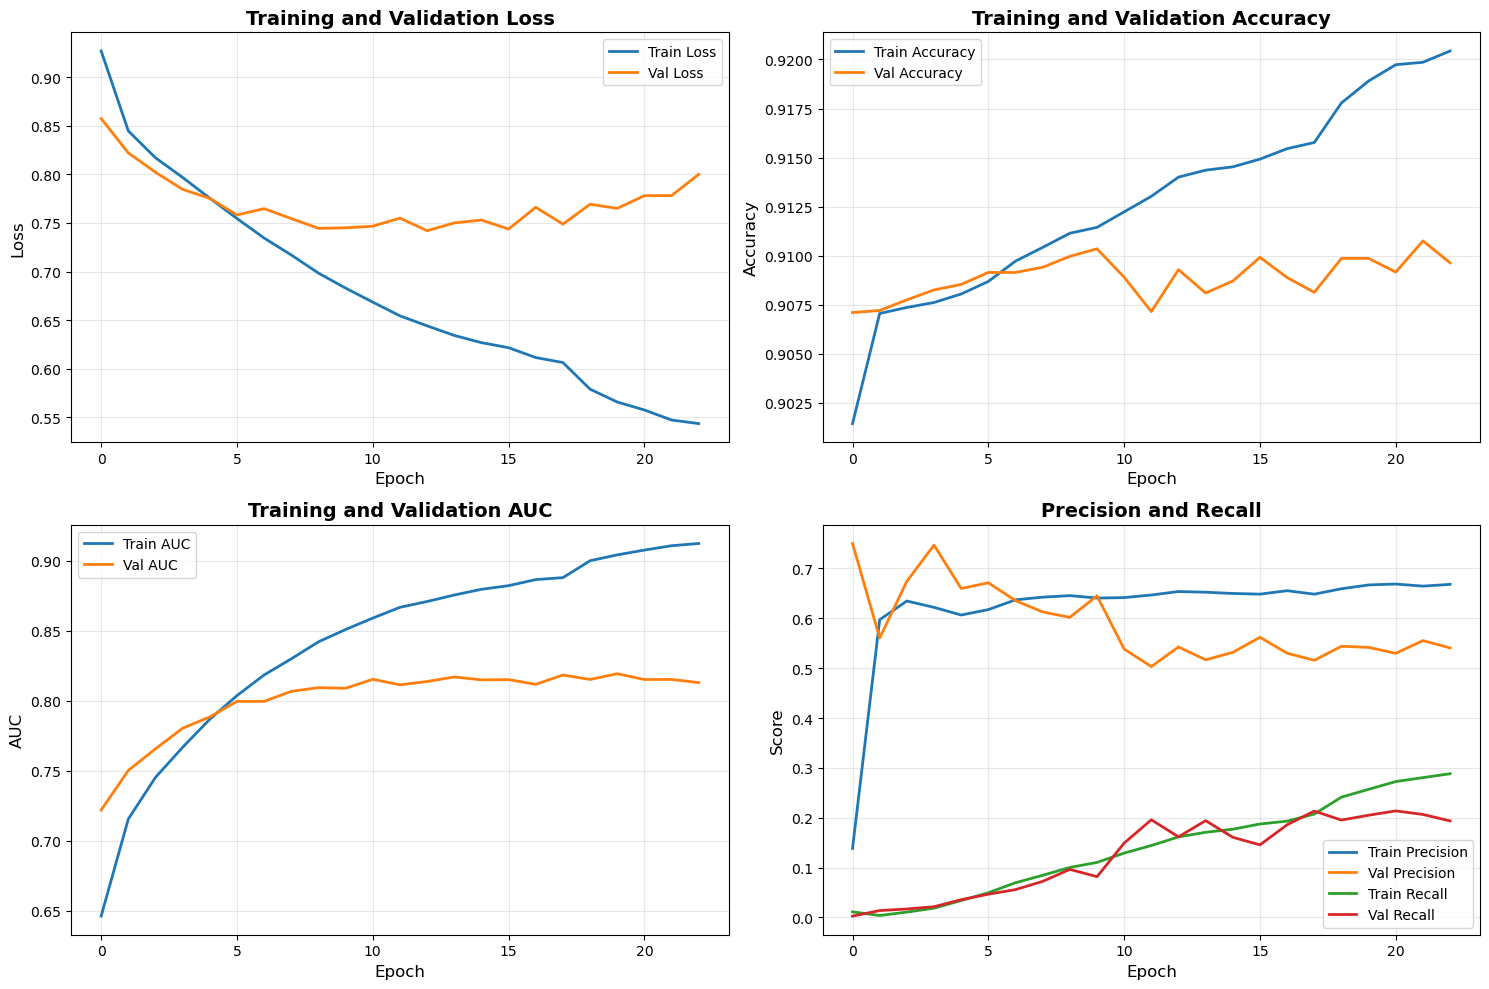

Training history plot saved to: ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_training_history.png


In [63]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['binary_accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_binary_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('AUC', fontsize=12)
axes[1, 0].set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Precision and Recall
axes[1, 1].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 1].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('Precision and Recall', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'transformer_gru_training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Training history plot saved to: {os.path.join(OUTPUT_DIR, 'transformer_gru_training_history.png')}")

## 10. Evaluation on Validation Set

In [64]:
# Get predictions on validation set
y_val_pred_proba = model.predict(X_val_embed, batch_size=BATCH_SIZE, verbose=1)
y_val_pred = (y_val_pred_proba > 0.5).astype(int)

print("\n" + "="*70)
print("VALIDATION SET EVALUATION")
print("="*70)

# Import additional metrics
from sklearn.metrics import precision_score, recall_score, matthews_corrcoef

# Per-label metrics
results = []

for i, label in enumerate(label_cols):
    print(f"\n{label}:")
    print("-" * 70)
    
    # Classification report
    report = classification_report(
        y_val[:, i],
        y_val_pred[:, i],
        target_names=['Negative', 'Positive'],
        digits=4,
        zero_division=0
    )
    print(report)
    
    # Calculate all metrics
    f1 = f1_score(y_val[:, i], y_val_pred[:, i], pos_label=1, zero_division=0)
    auc = roc_auc_score(y_val[:, i], y_val_pred_proba[:, i])
    precision = precision_score(y_val[:, i], y_val_pred[:, i], pos_label=1, zero_division=0)
    recall = recall_score(y_val[:, i], y_val_pred[:, i], pos_label=1, zero_division=0)
    mcc = matthews_corrcoef(y_val[:, i], y_val_pred[:, i])
    support = y_val[:, i].sum()
    
    results.append({
        'label': label,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'auc_roc': auc,
        'mcc': mcc,
        'support': support
    })
    
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"MCC:       {mcc:.4f}")

# Macro averages
macro_f1 = np.mean([r['f1_score'] for r in results])
macro_precision = np.mean([r['precision'] for r in results])
macro_recall = np.mean([r['recall'] for r in results])
macro_auc = np.mean([r['auc_roc'] for r in results])
macro_mcc = np.mean([r['mcc'] for r in results])

print("\n" + "="*70)
print("MACRO AVERAGES")
print("="*70)
print(f"Macro F1 Score:  {macro_f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro AUC-ROC:   {macro_auc:.4f}")
print(f"Macro MCC:       {macro_mcc:.4f}")
print("="*70)

# Save results with all metrics
results.append({
    'label': 'MACRO_AVERAGE',
    'f1_score': macro_f1,
    'precision': macro_precision,
    'recall': macro_recall,
    'auc_roc': macro_auc,
    'mcc': macro_mcc,
    'support': np.nan
})

results_df = pd.DataFrame(results)

# Reorder columns for better readability
column_order = ['label', 'f1_score', 'precision', 'recall', 'auc_roc', 'mcc', 'support']
results_df = results_df[column_order]

results_df.to_csv(os.path.join(OUTPUT_DIR, 'transformer_gru_results.csv'), index=False)
print(f"\nResults saved to: {os.path.join(OUTPUT_DIR, 'transformer_gru_results.csv')}")
print("\nResults table:")
print(results_df.to_string(index=False))

597/597 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step

VALIDATION SET EVALUATION

S-glutathionylation:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative     0.9402    0.9990    0.9687     17931
    Positive     0.4545    0.0130    0.0253      1155

    accuracy                         0.9393     19086
   macro avg     0.6974    0.5060    0.4970     19086
weighted avg     0.9108    0.9393    0.9116     19086

F1 Score:  0.0253
Precision: 0.4545
Recall:    0.0130
AUC-ROC:   0.8087
MCC:       0.0688

S-nitrosylation:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative     0.8508    0.9630    0.9034     15862
    Positive     0.4819    0.1694    0.2506      3224

    accuracy                         0.8289     19086
   macro avg     0.6664    0.5662    0.5770     19086
weighted avg     0.7885    0.8289    0.7932     19086

F1 S

## 11. Save Predictions for Ensemble

## 10b. (Optional) Recalculate Metrics from Saved Predictions

Run this cell to recalculate metrics without rerunning training or prediction.
Useful if you closed the notebook and want to update the results file.

In [72]:
# OPTIONAL: Run this to recalculate metrics from saved predictions
# Useful if you want to update results after closing the notebook

#Uncomment to run:
from sklearn.metrics import precision_score, recall_score, matthews_corrcoef

# Load true labels
val_data = pd.read_csv(VAL_FILE)
y_true_reload = val_data[label_cols].values

# Load predictions
pred_data = pd.read_csv(os.path.join(OUTPUT_DIR, 'transformer_gru_val_predictions.csv'))
y_pred_proba_reload = pred_data[['transformer_gru_glut_proba', 'transformer_gru_nitro_proba', 'transformer_gru_palm_proba']].values
y_pred_reload = (y_pred_proba_reload > 0.5).astype(int)

# Recalculate metrics
results_reload = []
for i, label in enumerate(label_cols):
    f1 = f1_score(y_true_reload[:, i], y_pred_reload[:, i], pos_label=1, zero_division=0)
    precision = precision_score(y_true_reload[:, i], y_pred_reload[:, i], pos_label=1, zero_division=0)
    recall = recall_score(y_true_reload[:, i], y_pred_reload[:, i], pos_label=1, zero_division=0)
    auc = roc_auc_score(y_true_reload[:, i], y_pred_proba_reload[:, i])
    mcc = matthews_corrcoef(y_true_reload[:, i], y_pred_reload[:, i])
    support = y_true_reload[:, i].sum()
    
    results_reload.append({
        'label': label,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'auc_roc': auc,
        'mcc': mcc,
        'support': support
    })
    print(f"{label}: F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, AUC={auc:.4f}, MCC={mcc:.4f}")

# Add macro averages
results_reload.append({
    'label': 'MACRO_AVERAGE',
    'f1_score': np.mean([r['f1_score'] for r in results_reload]),
    'precision': np.mean([r['precision'] for r in results_reload]),
    'recall': np.mean([r['recall'] for r in results_reload]),
    'auc_roc': np.mean([r['auc_roc'] for r in results_reload]),
    'mcc': np.mean([r['mcc'] for r in results_reload]),
    'support': np.nan
})

# Save updated results
results_df_reload = pd.DataFrame(results_reload)
results_df_reload = results_df_reload[['label', 'f1_score', 'precision', 'recall', 'auc_roc', 'mcc', 'support']]
results_df_reload.to_csv(os.path.join(OUTPUT_DIR, 'transformer_gru_results.csv'), index=False)
print(f"\n✓ Updated results saved to {os.path.join(OUTPUT_DIR, 'transformer_gru_results.csv')}")

print("This cell is commented out by default. Uncomment and run if you need to recalculate metrics from saved predictions.")

S-glutathionylation: F1=0.0253, Precision=0.4545, Recall=0.0130, AUC=0.8087, MCC=0.0688
S-nitrosylation: F1=0.2506, Precision=0.4819, Recall=0.1694, AUC=0.7980, MCC=0.2099
S-palmitoylation: F1=0.4385, Precision=0.7116, Recall=0.3168, AUC=0.8415, MCC=0.4581

✓ Updated results saved to ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_results.csv
This cell is commented out by default. Uncomment and run if you need to recalculate metrics from saved predictions.


## 10c. Threshold Optimization for Imbalanced Data

With severe class imbalance, the default threshold of 0.5 is too high!
Find optimal thresholds that maximize F1 score for each label.

In [66]:
from sklearn.metrics import precision_score, recall_score, matthews_corrcoef

print("="*70)
print("THRESHOLD OPTIMIZATION")
print("="*70)

# Analyze probability distributions
print("\n1. Probability Distribution Analysis:")
print("-"*70)
for i, label in enumerate(label_cols):
    pos_samples = y_val[:, i] == 1
    neg_samples = y_val[:, i] == 0
    
    pos_probs = y_val_pred_proba[pos_samples, i]
    neg_probs = y_val_pred_proba[neg_samples, i]
    
    print(f"\n{label}:")
    print(f"  Positive samples (n={pos_samples.sum()}):")
    print(f"    Mean prob: {pos_probs.mean():.4f}, Median: {np.median(pos_probs):.4f}")
    print(f"    Min: {pos_probs.min():.4f}, Max: {pos_probs.max():.4f}")
    print(f"  Negative samples (n={neg_samples.sum()}):")
    print(f"    Mean prob: {neg_probs.mean():.4f}, Median: {np.median(neg_probs):.4f}")
    print(f"    Min: {neg_probs.min():.4f}, Max: {neg_probs.max():.4f}")
    print(f"  → Problem: Positive samples have mean prob {pos_probs.mean():.4f} < 0.5 threshold!")

# Find optimal thresholds
print("\n" + "="*70)
print("2. Finding Optimal Thresholds (maximize F1):")
print("-"*70)

optimal_thresholds = {}
optimized_results = []

for i, label in enumerate(label_cols):
    print(f"\n{label}:")
    
    # Try thresholds from 0.01 to 0.99
    thresholds = np.arange(0.01, 1.0, 0.01)
    best_f1 = 0
    best_threshold = 0.5
    
    f1_scores = []
    for threshold in thresholds:
        y_pred_thresh = (y_val_pred_proba[:, i] > threshold).astype(int)
        f1 = f1_score(y_val[:, i], y_pred_thresh, zero_division=0)
        f1_scores.append(f1)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    optimal_thresholds[label] = best_threshold
    
    # Calculate all metrics with optimal threshold
    y_pred_optimal = (y_val_pred_proba[:, i] > best_threshold).astype(int)
    
    f1_optimal = f1_score(y_val[:, i], y_pred_optimal, zero_division=0)
    precision_optimal = precision_score(y_val[:, i], y_pred_optimal, zero_division=0)
    recall_optimal = recall_score(y_val[:, i], y_pred_optimal, zero_division=0)
    auc = roc_auc_score(y_val[:, i], y_val_pred_proba[:, i])
    mcc_optimal = matthews_corrcoef(y_val[:, i], y_pred_optimal)
    
    # Compare with 0.5 threshold
    y_pred_default = (y_val_pred_proba[:, i] > 0.5).astype(int)
    f1_default = f1_score(y_val[:, i], y_pred_default, zero_division=0)
    
    print(f"  Optimal threshold: {best_threshold:.3f}")
    print(f"  F1 @ 0.5 threshold:  {f1_default:.4f}")
    print(f"  F1 @ optimal:        {f1_optimal:.4f} (+{(f1_optimal-f1_default)*100:.1f}%)")
    print(f"  Precision: {precision_optimal:.4f}")
    print(f"  Recall:    {recall_optimal:.4f}")
    print(f"  MCC:       {mcc_optimal:.4f}")
    
    optimized_results.append({
        'label': label,
        'optimal_threshold': best_threshold,
        'f1_score': f1_optimal,
        'precision': precision_optimal,
        'recall': recall_optimal,
        'auc_roc': auc,
        'mcc': mcc_optimal,
        'support': y_val[:, i].sum()
    })

# Calculate macro averages
print("\n" + "="*70)
print("3. MACRO AVERAGES (Optimized Thresholds)")
print("="*70)

macro_f1_opt = np.mean([r['f1_score'] for r in optimized_results])
macro_precision_opt = np.mean([r['precision'] for r in optimized_results])
macro_recall_opt = np.mean([r['recall'] for r in optimized_results])
macro_auc_opt = np.mean([r['auc_roc'] for r in optimized_results])
macro_mcc_opt = np.mean([r['mcc'] for r in optimized_results])

print(f"Macro F1:        {macro_f1_opt:.4f}")
print(f"Macro Precision: {macro_precision_opt:.4f}")
print(f"Macro Recall:    {macro_recall_opt:.4f}")
print(f"Macro AUC:       {macro_auc_opt:.4f}")
print(f"Macro MCC:       {macro_mcc_opt:.4f}")

# Save optimized results
optimized_results.append({
    'label': 'MACRO_AVERAGE',
    'optimal_threshold': np.mean(list(optimal_thresholds.values())),
    'f1_score': macro_f1_opt,
    'precision': macro_precision_opt,
    'recall': macro_recall_opt,
    'auc_roc': macro_auc_opt,
    'mcc': macro_mcc_opt,
    'support': np.nan
})

optimized_df = pd.DataFrame(optimized_results)
column_order = ['label', 'optimal_threshold', 'f1_score', 'precision', 'recall', 'auc_roc', 'mcc', 'support']
optimized_df = optimized_df[column_order]

# Save to new file
optimized_results_path = os.path.join(OUTPUT_DIR, 'transformer_gru_results_optimized.csv')
optimized_df.to_csv(optimized_results_path, index=False)

print(f"\n✓ Optimized results saved to: {optimized_results_path}")
print("\n" + "="*70)
print("COMPARISON: Default (0.5) vs Optimized Thresholds")
print("="*70)
print(optimized_df.to_string(index=False))

# Save optimal thresholds for later use
thresholds_path = os.path.join(OUTPUT_DIR, 'optimal_thresholds.pkl')
with open(thresholds_path, 'wb') as f:
    pickle.dump(optimal_thresholds, f)
print(f"\n✓ Optimal thresholds saved to: {thresholds_path}")

THRESHOLD OPTIMIZATION

1. Probability Distribution Analysis:
----------------------------------------------------------------------

S-glutathionylation:
  Positive samples (n=1155):
    Mean prob: 0.1662, Median: 0.1351
    Min: 0.0001, Max: 0.6114
  Negative samples (n=17931):
    Mean prob: 0.0563, Median: 0.0196
    Min: 0.0000, Max: 0.6086
  → Problem: Positive samples have mean prob 0.1662 < 0.5 threshold!

S-nitrosylation:
  Positive samples (n=3224):
    Mean prob: 0.3532, Median: 0.3710
    Min: 0.0002, Max: 0.8510
  Negative samples (n=15862):
    Mean prob: 0.1636, Median: 0.1052
    Min: 0.0000, Max: 0.7701
  → Problem: Positive samples have mean prob 0.3532 < 0.5 threshold!

S-palmitoylation:
  Positive samples (n=950):
    Mean prob: 0.3504, Median: 0.1228
    Min: 0.0001, Max: 0.9986
  Negative samples (n=18136):
    Mean prob: 0.0327, Median: 0.0101
    Min: 0.0000, Max: 0.9910
  → Problem: Positive samples have mean prob 0.3504 < 0.5 threshold!

2. Finding Optimal Thr

## 10d. Visualize Threshold Optimization

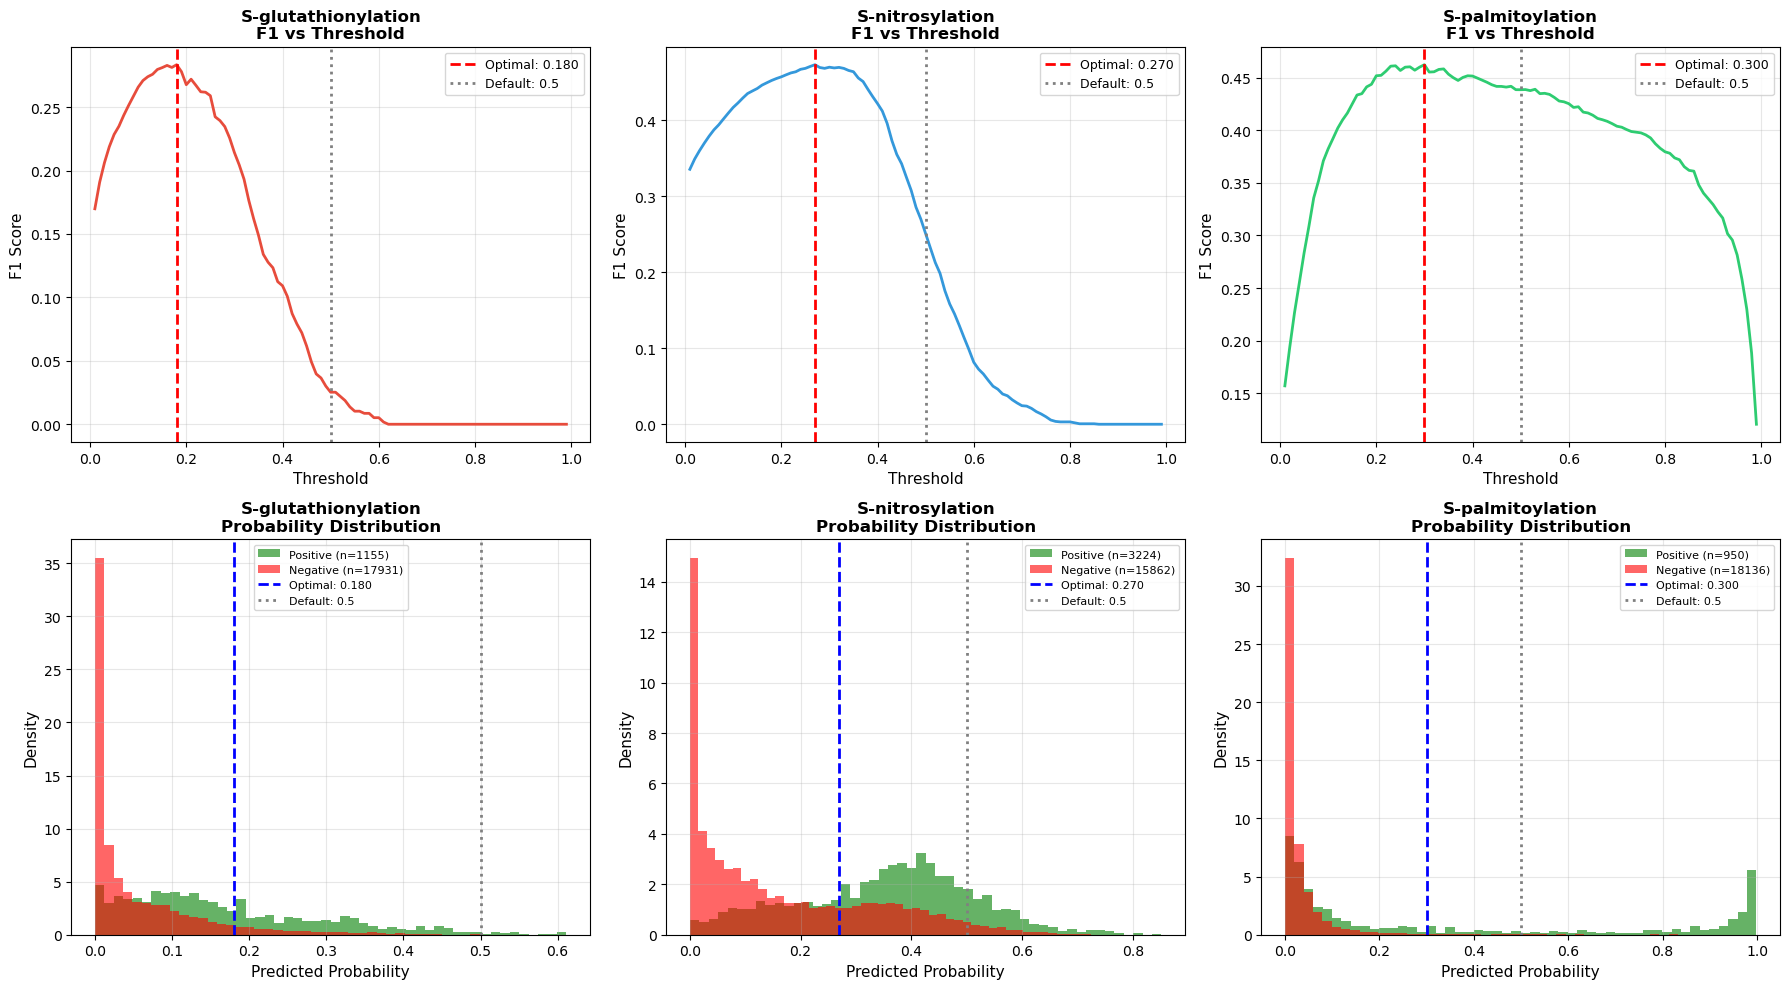

✓ Threshold optimization plot saved to: ../output/transformer_gru/run02_frozen_esm2_augmented_v2/threshold_optimization.png


In [67]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, (label, color) in enumerate(zip(label_cols, colors)):
    # Plot 1: F1 vs Threshold
    ax1 = axes[0, i]
    thresholds = np.arange(0.01, 1.0, 0.01)
    f1_scores = []
    
    for threshold in thresholds:
        y_pred_thresh = (y_val_pred_proba[:, i] > threshold).astype(int)
        f1 = f1_score(y_val[:, i], y_pred_thresh, zero_division=0)
        f1_scores.append(f1)
    
    ax1.plot(thresholds, f1_scores, color=color, linewidth=2)
    ax1.axvline(x=optimal_thresholds[label], color='red', linestyle='--', linewidth=2, 
                label=f'Optimal: {optimal_thresholds[label]:.3f}')
    ax1.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Default: 0.5')
    ax1.set_xlabel('Threshold', fontsize=11)
    ax1.set_ylabel('F1 Score', fontsize=11)
    ax1.set_title(f'{label}\nF1 vs Threshold', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Probability Distribution
    ax2 = axes[1, i]
    pos_samples = y_val[:, i] == 1
    neg_samples = y_val[:, i] == 0
    
    ax2.hist(y_val_pred_proba[pos_samples, i], bins=50, alpha=0.6, color='green', 
             label=f'Positive (n={pos_samples.sum()})', density=True)
    ax2.hist(y_val_pred_proba[neg_samples, i], bins=50, alpha=0.6, color='red', 
             label=f'Negative (n={neg_samples.sum()})', density=True)
    ax2.axvline(x=optimal_thresholds[label], color='blue', linestyle='--', linewidth=2, 
                label=f'Optimal: {optimal_thresholds[label]:.3f}')
    ax2.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Default: 0.5')
    ax2.set_xlabel('Predicted Probability', fontsize=11)
    ax2.set_ylabel('Density', fontsize=11)
    ax2.set_title(f'{label}\nProbability Distribution', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'threshold_optimization.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Threshold optimization plot saved to: {os.path.join(OUTPUT_DIR, 'threshold_optimization.png')}")

In [68]:
# Create predictions dataframe for ensemble
predictions_df = val_df[['ID']].copy()

# Add probability predictions with consistent naming
predictions_df['transformer_gru_glut_proba'] = y_val_pred_proba[:, 0]
predictions_df['transformer_gru_nitro_proba'] = y_val_pred_proba[:, 1]
predictions_df['transformer_gru_palm_proba'] = y_val_pred_proba[:, 2]

# Save predictions
predictions_path = os.path.join(OUTPUT_DIR, 'transformer_gru_val_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)

print(f"Predictions saved to: {predictions_path}")
print(f"\nPredictions shape: {predictions_df.shape}")
print("\nFirst few rows:")
print(predictions_df.head())

print("\nPrediction statistics:")
for col in ['transformer_gru_glut_proba', 'transformer_gru_nitro_proba', 'transformer_gru_palm_proba']:
    print(f"\n{col}:")
    print(f"  Mean: {predictions_df[col].mean():.4f}")
    print(f"  Std:  {predictions_df[col].std():.4f}")
    print(f"  Min:  {predictions_df[col].min():.4f}")
    print(f"  Max:  {predictions_df[col].max():.4f}")

Predictions saved to: ../output/transformer_gru/run02_frozen_esm2_augmented_v2/transformer_gru_val_predictions.csv

Predictions shape: (19086, 4)

First few rows:
       ID  transformer_gru_glut_proba  transformer_gru_nitro_proba  \
0  Q8IP90                    0.028266                     0.132407   
1  O00178                    0.001557                     0.066786   
2  P36897                    0.008536                     0.042830   
3  Q86UK7                    0.009175                     0.040206   
4  Q9HD20                    0.081919                     0.242078   

   transformer_gru_palm_proba  
0                    0.018379  
1                    0.000599  
2                    0.028992  
3                    0.806907  
4                    0.095865  

Prediction statistics:

transformer_gru_glut_proba:
  Mean: 0.0629
  Std:  0.0885
  Min:  0.0000
  Max:  0.6114

transformer_gru_nitro_proba:
  Mean: 0.1957
  Std:  0.1775
  Min:  0.0000
  Max:  0.8510

transformer_gru_palm

## 12. Visualization: ROC Curves

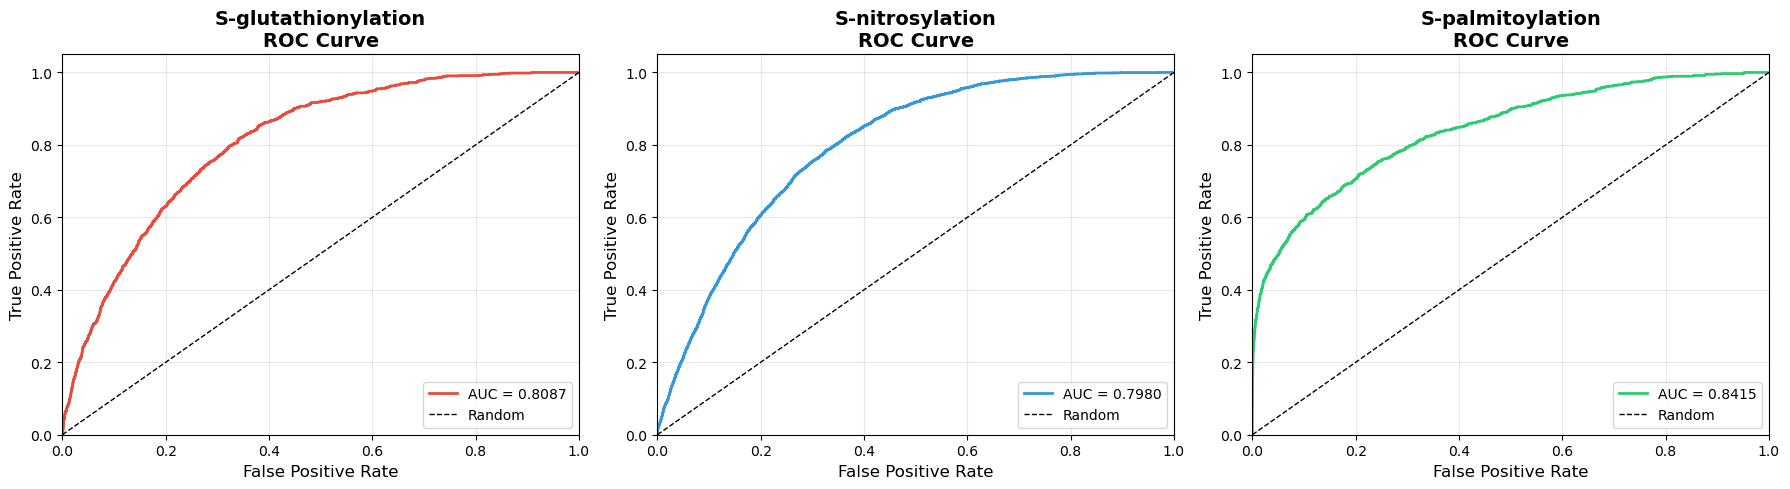

ROC curves saved to: ../output/transformer_gru/run02_frozen_esm2_augmented_v2/roc_curves.png


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, (label, color) in enumerate(zip(label_cols, colors)):
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_val[:, i], y_val_pred_proba[:, i])
    auc = roc_auc_score(y_val[:, i], y_val_pred_proba[:, i])
    
    # Plot
    axes[i].plot(fpr, tpr, color=color, linewidth=2, label=f'AUC = {auc:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    
    axes[i].set_xlabel('False Positive Rate', fontsize=12)
    axes[i].set_ylabel('True Positive Rate', fontsize=12)
    axes[i].set_title(f'{label}\nROC Curve', fontsize=14, fontweight='bold')
    axes[i].legend(fontsize=10, loc='lower right')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC curves saved to: {os.path.join(OUTPUT_DIR, 'roc_curves.png')}")

## 13. Visualization: Precision-Recall Curves

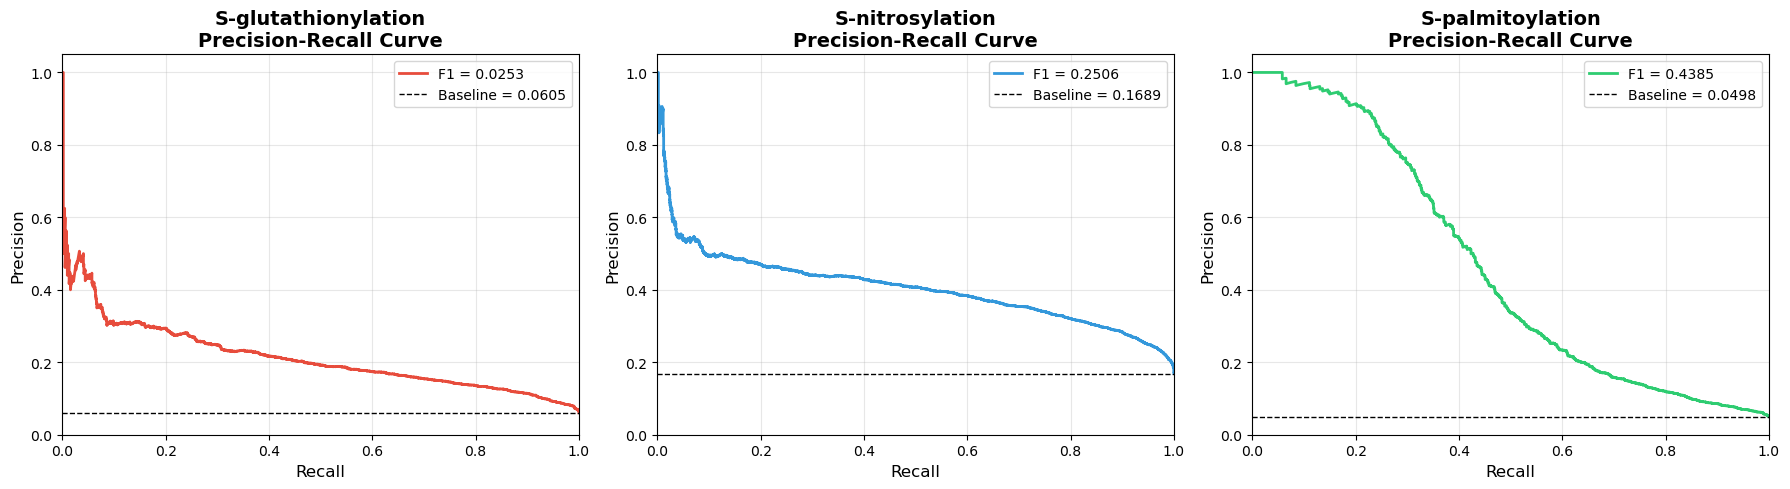

PR curves saved to: ../output/transformer_gru/run02_frozen_esm2_augmented_v2/precision_recall_curves.png


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (label, color) in enumerate(zip(label_cols, colors)):
    # Calculate PR curve
    precision, recall, _ = precision_recall_curve(y_val[:, i], y_val_pred_proba[:, i])
    f1 = f1_score(y_val[:, i], y_val_pred[:, i], zero_division=0)
    
    # Baseline (proportion of positives)
    baseline = y_val[:, i].mean()
    
    # Plot
    axes[i].plot(recall, precision, color=color, linewidth=2, label=f'F1 = {f1:.4f}')
    axes[i].axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline = {baseline:.4f}')
    
    axes[i].set_xlabel('Recall', fontsize=12)
    axes[i].set_ylabel('Precision', fontsize=12)
    axes[i].set_title(f'{label}\nPrecision-Recall Curve', fontsize=14, fontweight='bold')
    axes[i].legend(fontsize=10, loc='best')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'precision_recall_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"PR curves saved to: {os.path.join(OUTPUT_DIR, 'precision_recall_curves.png')}")

## 14. Summary

In [71]:
print("\n" + "="*70)
print("TRANSFORMER+GRU TRAINING SUMMARY")
print("="*70)
print(f"\nModel: {ESM_MODEL_NAME}")
print(f"Training Mode: {'Phase 2 - Fine-tuning' if USE_FINETUNING else 'Phase 1 - Frozen Features'}")
print(f"\nArchitecture:")
print(f"  - Embedding Dim: {EMBEDDING_DIM}")
print(f"  - GRU Units: {GRU_UNITS}")
print(f"  - Dense Units: {DENSE_UNITS}")
print(f"  - Trainable Parameters: {trainable_params:,}")
print(f"\nTraining:")
print(f"  - Duration: {training_duration}")
print(f"  - Epochs: {len(history.history['loss'])}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Learning Rate: {learning_rate}")
print(f"\nPerformance:")
print(f"  - Macro F1 Score: {macro_f1:.4f}")
print(f"  - Macro AUC-ROC: {macro_auc:.4f}")
print(f"\nPer-label F1 Scores:")
for result in results[:-1]:  # Exclude macro average
    print(f"  - {result['label']}: {result['f1_score']:.4f}")
print(f"\nOutput Directory: {OUTPUT_DIR}")
print(f"\nFiles Generated:")
print(f"  - transformer_gru_model_best.h5")
print(f"  - transformer_gru_model_final.h5")
print(f"  - transformer_gru_val_predictions.csv")
print(f"  - transformer_gru_results.csv")
print(f"  - training_history.csv")
print(f"  - model_config.json")
print(f"  - transformer_gru_training_history.png")
print(f"  - roc_curves.png")
print(f"  - precision_recall_curves.png")
print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)


TRANSFORMER+GRU TRAINING SUMMARY

Model: esm2_t12_35M_UR50D
Training Mode: Phase 1 - Frozen Features

Architecture:
  - Embedding Dim: 480
  - GRU Units: [128, 64]
  - Dense Units: [128, 64]
  - Trainable Parameters: 617,475

Training:
  - Duration: 0:59:26.777370
  - Epochs: 23
  - Batch Size: 32
  - Learning Rate: 0.001

Performance:
  - Macro F1 Score: 0.2381
  - Macro AUC-ROC: 0.8161

Per-label F1 Scores:
  - S-glutathionylation: 0.0253
  - S-nitrosylation: 0.2506
  - S-palmitoylation: 0.4385

Output Directory: ../output/transformer_gru/run02_frozen_esm2_augmented_v2

Files Generated:
  - transformer_gru_model_best.h5
  - transformer_gru_model_final.h5
  - transformer_gru_val_predictions.csv
  - transformer_gru_results.csv
  - training_history.csv
  - model_config.json
  - transformer_gru_training_history.png
  - roc_curves.png
  - precision_recall_curves.png

TRAINING COMPLETE!
